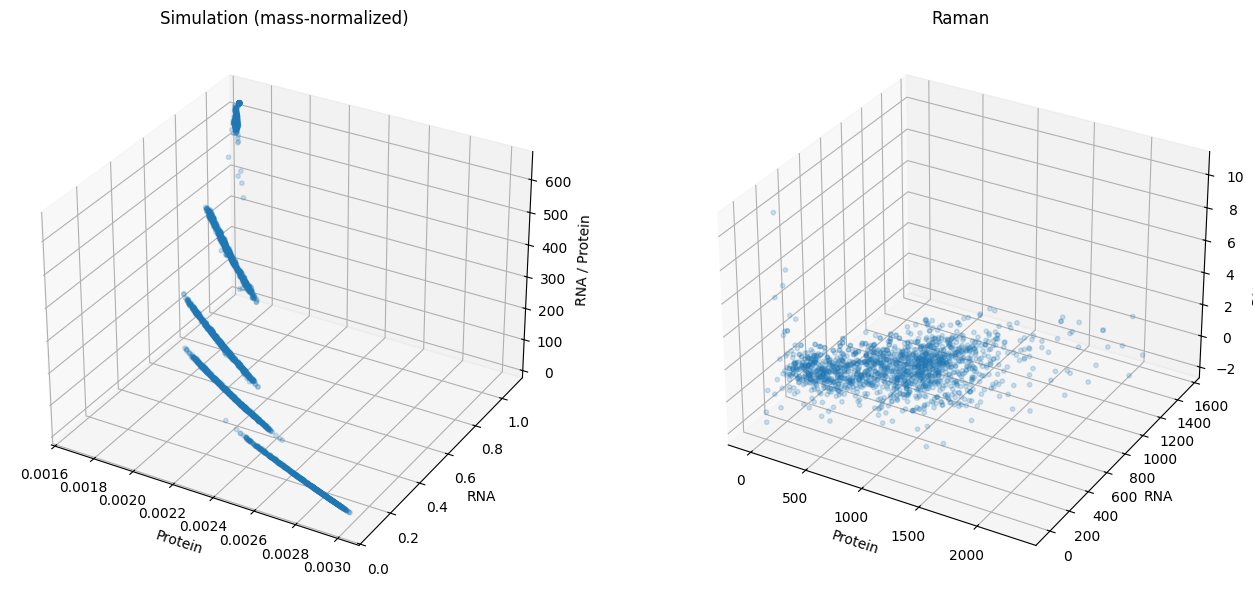

In [6]:
# ============================================================
# 3D SCATTER: RNA, Protein, Ratio (Simulation vs Raman)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pyarrow as pa
import pyarrow.ipc as ipc

# ----------------------------
# PARAMETERS
# ----------------------------
NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565
BURN_IN = 1000.0

nutrients = ["gly", "glu", "caa_gly", "caa_glu"]
cm_levels = [0, 2, 4, 8, 12]

# ----------------------------
# HELPERS
# ----------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_protein(df):
    return (df["r(t)"] + df["q(t)"] + df["et(t)"] + df["em(t)"]).to_numpy()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)
    return ribo_mass + non_ribo

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()

# ============================================================
# BUILD SIMULATION CLOUD (all ns, all abx)
# ============================================================

sim_prot, sim_rna = [], []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        if abx == 0:
            path = f"Data/ns{int(ns*100):03d}.arrow"
        else:
            path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        total_mass = compute_mass(df)
        protein = compute_protein(df) / total_mass
        rna     = compute_RNA_nt(df) / total_mass

        # Subsample for clarity
        idx = np.random.choice(len(protein), size=min(200, len(protein)), replace=False)

        sim_prot.append(protein[idx])
        sim_rna.append(rna[idx])

sim_prot = np.concatenate(sim_prot)
sim_rna  = np.concatenate(sim_rna)
sim_ratio = sim_rna / sim_prot

# ============================================================
# BUILD RAMAN CLOUD (using precomputed ratio)
# ============================================================

rna_df     = pd.read_csv("Data/RamanData/rna.csv")
protein_df = pd.read_csv("Data/RamanData/protein.csv")
ratio_df   = pd.read_csv("Data/RamanData/rna_protein.csv")

raman_prot, raman_rna, raman_ratio = [], [], []

for nutrient in nutrients:
    for cm in cm_levels:

        col = f"Cm{cm}_{nutrient}"

        if (
            col not in rna_df.columns or
            col not in protein_df.columns or
            col not in ratio_df.columns
        ):
            continue

        RNA   = rna_df[col].dropna().values
        PROT  = protein_df[col].dropna().values
        RATIO = ratio_df[col].dropna().values

        N = min(len(RNA), len(PROT), len(RATIO))

        raman_prot.append(PROT[:N])
        raman_rna.append(RNA[:N])
        raman_ratio.append(RATIO[:N])

raman_prot  = np.concatenate(raman_prot)
raman_rna   = np.concatenate(raman_rna)
raman_ratio = np.concatenate(raman_ratio)


# ============================================================
# 3D PLOTS
# ============================================================

fig = plt.figure(figsize=(14,6))

# --- Simulation ---
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(sim_prot, sim_rna, sim_ratio,
            s=10, alpha=0.2)
ax1.set_title("Simulation (mass-normalized)")
ax1.set_xlabel("Protein")
ax1.set_ylabel("RNA")
ax1.set_zlabel("RNA / Protein")

# --- Raman ---
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(raman_prot, raman_rna, raman_ratio,
            s=10, alpha=0.2)
ax2.set_title("Raman")
ax2.set_xlabel("Protein")
ax2.set_ylabel("RNA")
ax2.set_zlabel("RNA / Protein")

plt.tight_layout()
plt.show()


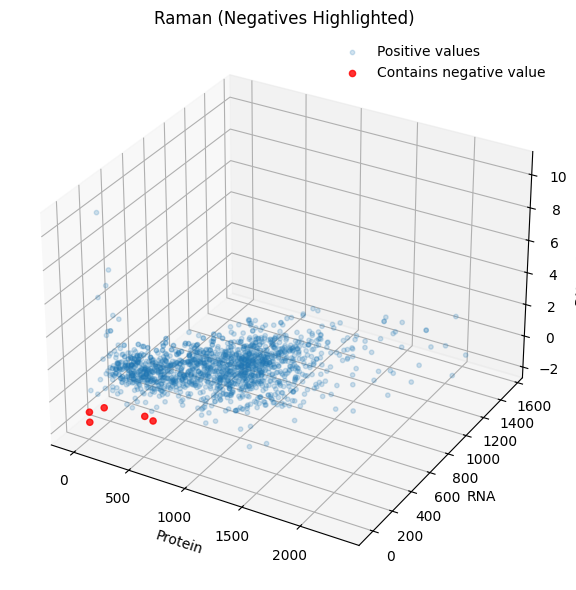

Total points: 1580
Points with any negative value: 5
Percent negative: 0.31645569620253167 %


In [7]:
# ============================================================
# 3D RAMAN WITH NEGATIVES HIGHLIGHTED
# ============================================================

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

# Mask for negative values in ANY axis
neg_mask = (
    (raman_prot < 0) |
    (raman_rna < 0) |
    (raman_ratio < 0)
)

# Positive points
ax.scatter(
    raman_prot[~neg_mask],
    raman_rna[~neg_mask],
    raman_ratio[~neg_mask],
    s=10,
    alpha=0.2,
    label="Positive values"
)

# Negative points
ax.scatter(
    raman_prot[neg_mask],
    raman_rna[neg_mask],
    raman_ratio[neg_mask],
    s=20,
    alpha=0.8,
    color="red",
    label="Contains negative value"
)

ax.set_title("Raman (Negatives Highlighted)")
ax.set_xlabel("Protein")
ax.set_ylabel("RNA")
ax.set_zlabel("RNA / Protein")

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print("Total points:", len(raman_prot))
print("Points with any negative value:", np.sum(neg_mask))
print("Percent negative:", 100*np.mean(neg_mask), "%")


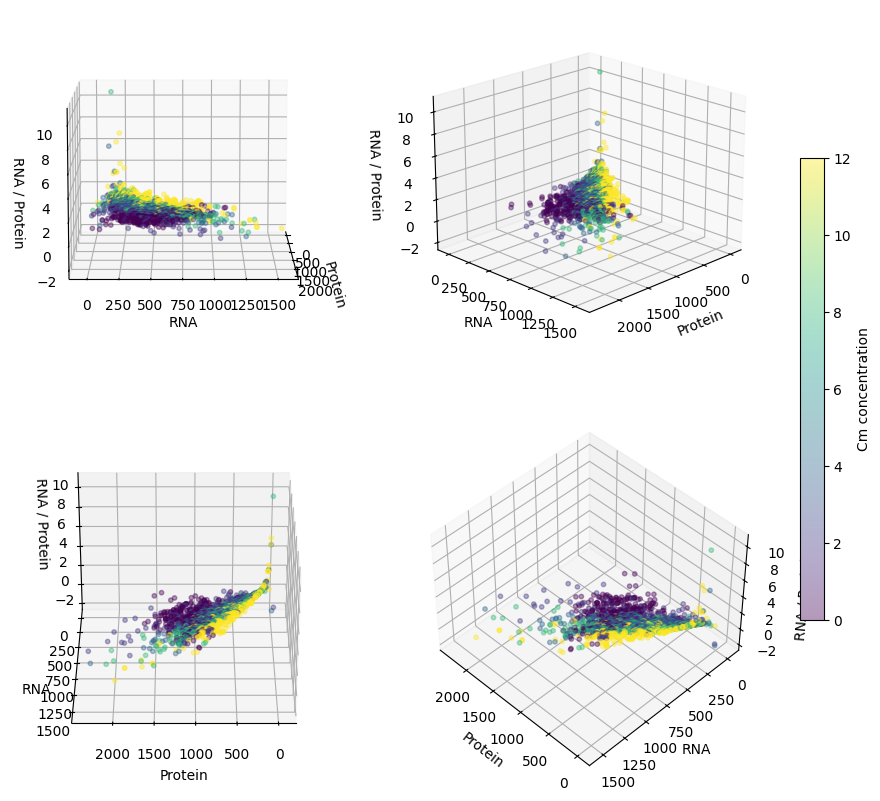

In [14]:
# ============================================================
# 3D ANGLE SWEEP — RAMAN (COLORED BY CM)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ------------------------------------------------------------
# LOAD RAMAN DATA
# ------------------------------------------------------------

rna_df     = pd.read_csv("Data/RamanData/rna.csv")
protein_df = pd.read_csv("Data/RamanData/protein.csv")
ratio_df   = pd.read_csv("Data/RamanData/rna_protein.csv")

nutrients = ["gly", "glu", "caa_gly", "caa_glu"]
cm_levels = [0, 2, 4, 8, 12]

raman_prot, raman_rna, raman_ratio, raman_cm = [], [], [], []

for nutrient in nutrients:
    for cm_val in cm_levels:

        col = f"Cm{cm_val}_{nutrient}"

        if (
            col not in rna_df.columns or
            col not in protein_df.columns or
            col not in ratio_df.columns
        ):
            continue

        RNA   = rna_df[col].dropna().values
        PROT  = protein_df[col].dropna().values
        RATIO = ratio_df[col].dropna().values

        N = min(len(RNA), len(PROT), len(RATIO))

        raman_rna.append(RNA[:N])
        raman_prot.append(PROT[:N])
        raman_ratio.append(RATIO[:N])
        raman_cm.append(np.full(N, cm_val))

raman_rna   = np.concatenate(raman_rna)
raman_prot  = np.concatenate(raman_prot)
raman_ratio = np.concatenate(raman_ratio)
raman_cm    = np.concatenate(raman_cm)

# ------------------------------------------------------------
# COLOR MAP
# ------------------------------------------------------------

norm = mcolors.Normalize(vmin=0, vmax=12)
cmap = cm.viridis

# ------------------------------------------------------------
# 3D ANGLE SWEEP
# ------------------------------------------------------------

fig = plt.figure(figsize=(12,10))

angles = [(10,0), (20,45), (30,90), (45,135)]

for i, (elev, azim) in enumerate(angles):

    ax = fig.add_subplot(2, 2, i+1, projection='3d')

    sc = ax.scatter(
        raman_prot,
        raman_rna,
        raman_ratio,
        c=raman_cm,
        cmap=cmap,
        norm=norm,
        s=10,
        alpha=0.4
    )

    ax.view_init(elev=elev, azim=azim)

    ax.set_xlabel("Protein")
    ax.set_ylabel("RNA")
    ax.set_zlabel("RNA / Protein")

# Shared colorbar
cbar = fig.colorbar(sc, ax=fig.axes, shrink=0.6)
cbar.set_label("Cm concentration")

# plt.tight_layout()
plt.show()


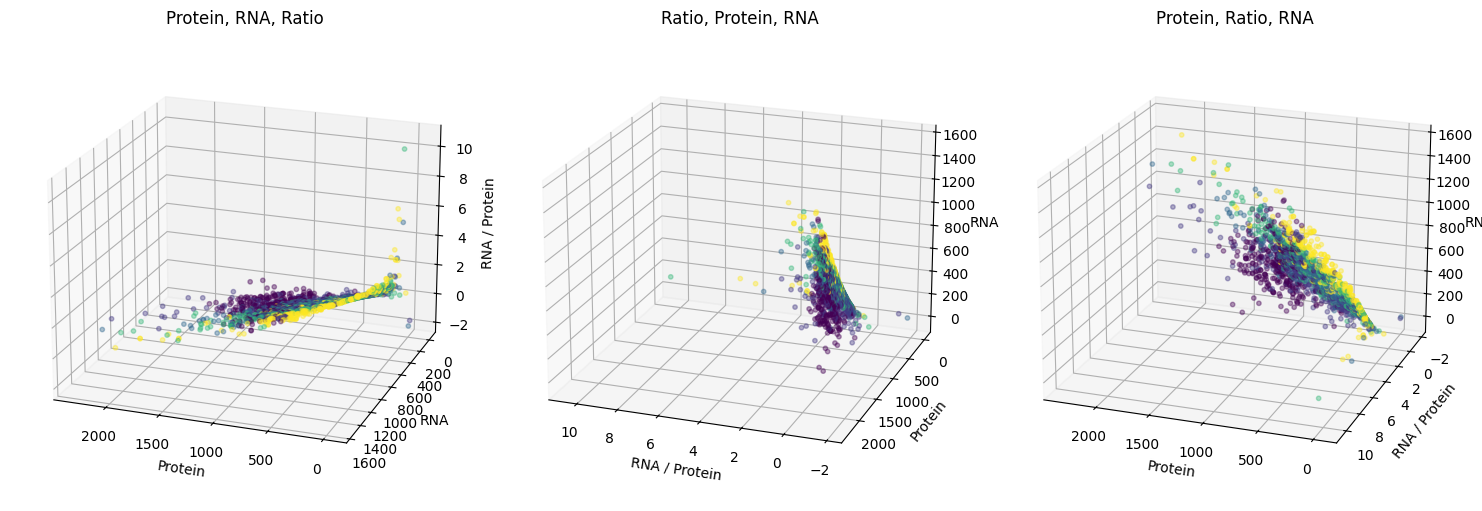

In [18]:
# ============================================================
# RAMAN 3D AXIS PERMUTATION VIEW
# ============================================================

fig = plt.figure(figsize=(15,5))

norm = plt.Normalize(vmin=0, vmax=12)
cmap = plt.cm.viridis

# --- 1. Original ---
ax1 = fig.add_subplot(131, projection='3d')
sc1 = ax1.scatter(
    raman_prot, raman_rna, raman_ratio,
    c=raman_cm, cmap=cmap, norm=norm,
    s=10, alpha=0.4
)
ax1.set_title("Protein, RNA, Ratio")
ax1.set_xlabel("Protein")
ax1.set_ylabel("RNA")
ax1.set_zlabel("RNA / Protein")
ax1.view_init(elev=20, azim=110)

# --- 2. Ratio first ---
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(
    raman_ratio, raman_prot, raman_rna,
    c=raman_cm, cmap=cmap, norm=norm,
    s=10, alpha=0.4
)
ax2.set_title("Ratio, Protein, RNA")
ax2.set_xlabel("RNA / Protein")
ax2.set_ylabel("Protein")
ax2.set_zlabel("RNA")
ax2.view_init(elev=20, azim=110)

# --- 3. Ratio middle ---
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(
    raman_prot, raman_ratio, raman_rna,
    c=raman_cm, cmap=cmap, norm=norm,
    s=10, alpha=0.4
)
ax3.set_title("Protein, Ratio, RNA")
ax3.set_xlabel("Protein")
ax3.set_ylabel("RNA / Protein")
ax3.set_zlabel("RNA")
ax3.view_init(elev=20, azim=110)

plt.tight_layout()
plt.show()


In [32]:
import plotly.express as px
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Build DataFrame
# ------------------------------------------------------------

df_plot = pd.DataFrame({
    "Protein": raman_prot,
    "RNA": raman_rna,
    "Ratio": raman_ratio,
    "Cm": raman_cm
})

# ------------------------------------------------------------
# FILTER NEGATIVE VALUES
# ------------------------------------------------------------

neg_mask = (
    (df_plot["Protein"] < 0) |
    (df_plot["RNA"] < 0) |
    (df_plot["Ratio"] < 0)
)

print("Total points:", len(df_plot))
print("Negative points removed:", neg_mask.sum())
print("Percent removed:", 100 * neg_mask.mean(), "%")

df_plot = df_plot[~neg_mask].reset_index(drop=True)

# ------------------------------------------------------------
# INTERACTIVE 3D SCATTER
# ------------------------------------------------------------

fig = px.scatter_3d(
    df_plot,
    x="Protein",
    y="RNA",
    z="Ratio",
    color="Cm",
    color_continuous_scale="Viridis",
    opacity=0.5
)

fig.update_layout(
    scene=dict(
        xaxis_title="Protein",
        yaxis_title="RNA",
        zaxis_title="RNA / Protein"
    ),
    width=900,
    height=700
)

fig.show()
fig.write_html("raman_3d_interactive.html")

Total points: 1580
Negative points removed: 5
Percent removed: 0.31645569620253167 %


In [35]:
import numpy as np
import pandas as pd
import plotly.express as px
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565
BURN_IN = 1000.0

# ============================================================
# HELPERS
# ============================================================

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_protein(df):
    return (df["r(t)"] + df["q(t)"] + df["et(t)"] + df["em(t)"]).to_numpy()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)
    return ribo_mass + non_ribo

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()

# ============================================================
# BUILD DATAFRAME
# ============================================================

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        if abx == 0:
            path = f"Data/ns{int(ns*100):03d}.arrow"
        else:
            path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        total_mass = compute_mass(df)

        protein = compute_mass(df)
        rna     = compute_RNA_nt(df)
        ratio   = rna / protein

        # Subsample for clarity
        idx = np.random.choice(len(protein), size=min(200, len(protein)), replace=False)

        for i in idx:
            records.append({
                "Protein": protein[i],
                "RNA": rna[i],
                "Ratio": ratio[i],
                "ABX": abx,
                "NS": ns
            })

df_sim_plot = pd.DataFrame(records)

# ============================================================
# OPTIONAL: REMOVE NEGATIVE VALUES
# ============================================================

neg_mask = (
    (df_sim_plot["Protein"] < 0) |
    (df_sim_plot["RNA"] < 0) |
    (df_sim_plot["Ratio"] < 0)
)

print("Negative points removed:", neg_mask.sum())

df_sim_plot = df_sim_plot[~neg_mask]

# ============================================================
# INTERACTIVE 3D PLOT
# ============================================================

fig = px.scatter_3d(
    df_sim_plot,
    x="Protein",
    y="RNA",
    z="Ratio",
    color="ABX",
    color_continuous_scale="Viridis",
    opacity=0.5,
    hover_data=["NS"]
)

fig.update_layout(
    scene=dict(
        xaxis_title="Protein (total cellular mass)",
        yaxis_title="RNA",
        zaxis_title="RNA / Protein"
    ),
    width=900,
    height=750
)

fig.show()

# Optional: save interactive file
# fig.write_html("simulation_3d_interactive.html")

Negative points removed: 0


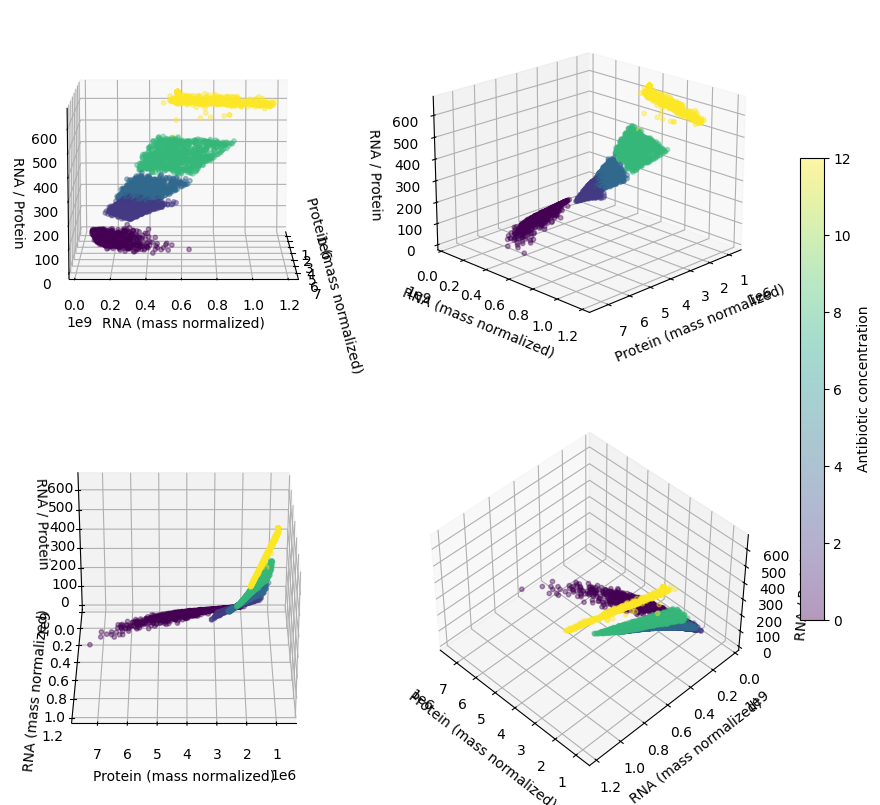

In [ ]:
# ============================================================
# 3D ANGLE SWEEP — SIMULATION (COLORED BY ABX)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pyarrow as pa
import pyarrow.ipc as ipc

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565
BURN_IN = 1000.0

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_protein(df):
    return (df["r(t)"] + df["q(t)"] + df["et(t)"] + df["em(t)"]).to_numpy()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)
    return ribo_mass + non_ribo

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()

sim_prot, sim_rna, sim_ratio, sim_abx = [], [], [], []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        total_mass = compute_mass(df)

        protein = compute_protein(df) #/ total_mass
        rna     = compute_RNA_nt(df) #/ total_mass
        ratio   = rna / protein

        idx = np.random.choice(len(protein), size=min(200, len(protein)), replace=False)

        sim_prot.append(protein[idx])
        sim_rna.append(rna[idx])
        sim_ratio.append(ratio[idx])
        sim_abx.append(np.full(len(idx), abx))

sim_prot  = np.concatenate(sim_prot)
sim_rna   = np.concatenate(sim_rna)
sim_ratio = np.concatenate(sim_ratio)
sim_abx   = np.concatenate(sim_abx)

norm = mcolors.Normalize(vmin=0, vmax=12)
cmap = cm.viridis

fig = plt.figure(figsize=(12,10))

angles = [(10,0), (20,45), (30,90), (45,135)]

for i, (elev, azim) in enumerate(angles):

    ax = fig.add_subplot(2, 2, i+1, projection='3d')

    sc = ax.scatter(
        sim_prot,
        sim_rna,
        sim_ratio,
        c=sim_abx,
        cmap=cmap,
        norm=norm,
        s=10,
        alpha=0.4
    )

    ax.view_init(elev=elev, azim=azim)

    ax.set_xlabel("Protein (mass normalized)")
    ax.set_ylabel("RNA (mass normalized)")
    ax.set_zlabel("RNA / Protein")

cbar = fig.colorbar(sc, ax=fig.axes, shrink=0.6)
cbar.set_label("Antibiotic concentration")

plt.show()


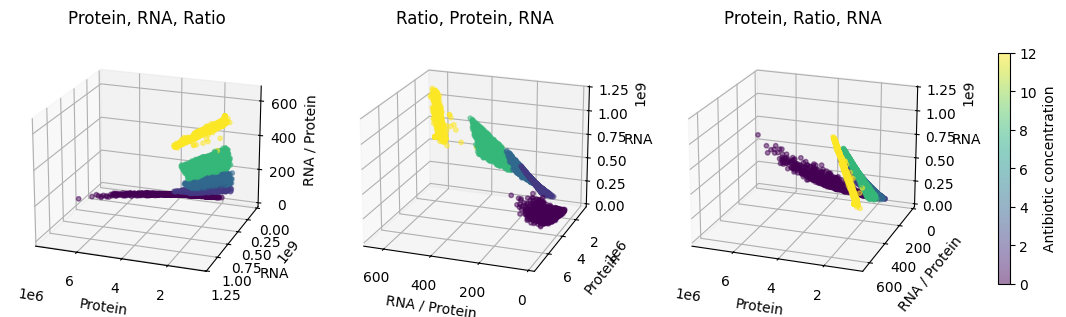

In [22]:
# ============================================================
# SIMULATION 3D AXIS PERMUTATION VIEW
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

norm = mcolors.Normalize(vmin=0, vmax=12)
cmap = cm.viridis

fig = plt.figure(figsize=(15,5))

# ------------------------------------------------------------
# 1. Protein, RNA, Ratio  (original orientation)
# ------------------------------------------------------------
ax1 = fig.add_subplot(131, projection='3d')
sc1 = ax1.scatter(
    sim_prot, sim_rna, sim_ratio,
    c=sim_abx, cmap=cmap, norm=norm,
    s=10, alpha=0.5
)

ax1.set_title("Protein, RNA, Ratio")
ax1.set_xlabel("Protein")
ax1.set_ylabel("RNA")
ax1.set_zlabel("RNA / Protein")
ax1.view_init(elev=20, azim=110)

# ------------------------------------------------------------
# 2. Ratio, Protein, RNA
# ------------------------------------------------------------
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(
    sim_ratio, sim_prot, sim_rna,
    c=sim_abx, cmap=cmap, norm=norm,
    s=10, alpha=0.5
)

ax2.set_title("Ratio, Protein, RNA")
ax2.set_xlabel("RNA / Protein")
ax2.set_ylabel("Protein")
ax2.set_zlabel("RNA")
ax2.view_init(elev=20, azim=110)

# ------------------------------------------------------------
# 3. Protein, Ratio, RNA
# ------------------------------------------------------------
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(
    sim_prot, sim_ratio, sim_rna,
    c=sim_abx, cmap=cmap, norm=norm,
    s=10, alpha=0.5
)

ax3.set_title("Protein, Ratio, RNA")
ax3.set_xlabel("Protein")
ax3.set_ylabel("RNA / Protein")
ax3.set_zlabel("RNA")
ax3.view_init(elev=20, azim=110)

# Shared colorbar
cbar = fig.colorbar(sc1, ax=[ax1, ax2, ax3], shrink=0.6)
cbar.set_label("Antibiotic concentration")

plt.show()


PCA DIMENSIONALITY COMPARISON
Simulation vs Raman

In [24]:
# ============================================================
# PCA DIMENSIONALITY COMPARISON
# Simulation vs Raman
# ============================================================

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def run_pca(X, label):
    """
    X: array (n_samples, 3)
    label: string
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=3)
    pca.fit(X_scaled)

    explained = pca.explained_variance_ratio_

    print(f"\n=== {label} PCA Results ===")
    print(f"PC1 variance explained: {explained[0]:.4f}")
    print(f"PC2 variance explained: {explained[1]:.4f}")
    print(f"PC3 variance explained: {explained[2]:.4f}")
    print(f"Cumulative PC1+PC2:     {explained[0] + explained[1]:.4f}")

    return explained


# ------------------------------------------------------------
# Prepare Simulation matrix
# ------------------------------------------------------------

X_sim = np.column_stack([
    sim_prot,
    sim_rna,
    sim_ratio
])

sim_explained = run_pca(X_sim, "Simulation")


# ------------------------------------------------------------
# Prepare Raman matrix
# ------------------------------------------------------------

X_raman = np.column_stack([
    raman_prot,
    raman_rna,
    raman_ratio
])

raman_explained = run_pca(X_raman, "Raman")



=== Simulation PCA Results ===
PC1 variance explained: 0.7790
PC2 variance explained: 0.1955
PC3 variance explained: 0.0255
Cumulative PC1+PC2:     0.9745

=== Raman PCA Results ===
PC1 variance explained: 0.6081
PC2 variance explained: 0.3290
PC3 variance explained: 0.0629
Cumulative PC1+PC2:     0.9371


| Dataset    | PC1 dominance | 2D structure | Noise level |
| ---------- | ------------- | ------------ | ----------- |
| Simulation | Strong        | Very strong  | Low         |
| Raman      | Moderate      | Strong       | Higher      |


Both datasets are fundamentally low-dimensional. But Raman data shows extra variability orthogonal to the core manifold.

PCA analysis reveals that both the stochastic simulation and Raman data occupy a predominantly low-dimensional subspace in RNA–protein–ratio space. The simulation exhibits stronger dimensional compression, with ~78% variance explained by a single principal component, compared to ~61% in Raman data. However, in both datasets >93% of variance lies within two principal components, supporting the hypothesis that ribosomal allocation dynamics impose strong global constraints on cellular composition. The increased dimensionality in Raman likely reflects biological and measurement variability rather than fundamentally different structure.

In [27]:
# ===============================================================
# WHAT DOES RNA / PROTEIN REPRESENT?
# Full self-contained version with growth rate defined
# ===============================================================

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc

# --------------------------------------------------------------
# PARAMETERS
# --------------------------------------------------------------

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0
RIBO_RNA_NT = 4565

# --------------------------------------------------------------
# HELPERS
# --------------------------------------------------------------

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    r = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )
    q = df["q(t)"] + df["et(t)"] + df["em(t)"]

    ribo_mass = NR * r.to_numpy()
    prot_mass = NX * q.to_numpy()

    return ribo_mass, prot_mass

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()

def compute_growth_rate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)

    active = (
        df["rmr(t)"] +
        df["rmt(t)"] +
        df["rmm(t)"] +
        df["rmq(t)"]
    ).to_numpy()

    return (active * gamma / mass) * 60.0  # per hour

# --------------------------------------------------------------
# MAIN ANALYSIS
# --------------------------------------------------------------

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        # Correct file path logic
        if abx == 0:
            path = f"Data/ns{int(ns*100):03d}.arrow"
        else:
            path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        ribo_mass, prot_mass = compute_mass(df)
        total_mass = ribo_mass + prot_mass

        phiR = ribo_mass / total_mass
        rna = compute_RNA_nt(df)
        protein = prot_mass
        ratio = rna / protein
        lam = compute_growth_rate(df, total_mass)

        valid = (
            ~np.isnan(phiR) &
            ~np.isnan(ratio) &
            ~np.isnan(lam) &
            (protein > 0)
        )

        phiR = phiR[valid]
        ratio = ratio[valid]
        lam = lam[valid]

        if len(phiR) < 10:
            continue

        corr_ratio_phiR = np.corrcoef(ratio, phiR)[0,1]
        corr_ratio_lambda = np.corrcoef(ratio, lam)[0,1]
        corr_phiR_lambda = np.corrcoef(phiR, lam)[0,1]
        slope_ratio_phiR = np.polyfit(phiR, ratio, 1)[0]

        records.append({
            "ns": ns,
            "abx": abx,
            "corr_ratio_phiR": corr_ratio_phiR,
            "corr_ratio_lambda": corr_ratio_lambda,
            "corr_phiR_lambda": corr_phiR_lambda,
            "slope_ratio_vs_phiR": slope_ratio_phiR,
            "mean_lambda": lam.mean(),
            "mean_phiR": phiR.mean(),
            "mean_ratio": ratio.mean()
        })

df_ratio_mechanism = pd.DataFrame(records)

print("\n=== Mechanistic Meaning of RNA/Protein ===\n")
print(df_ratio_mechanism.sort_values(["ns","abx"]))



=== Mechanistic Meaning of RNA/Protein ===

      ns  abx  corr_ratio_phiR  corr_ratio_lambda  corr_phiR_lambda  \
0   0.45    0         0.999364           0.605337          0.590724   
1   0.45    2         0.996235           0.780578          0.767017   
2   0.45    4         0.992292           0.682854          0.674381   
3   0.45    8         0.984671           0.591846          0.586774   
4   0.45   12         0.952249          -0.622547         -0.376433   
5   0.74    0         0.998839           0.660100          0.643962   
6   0.74    2         0.996608           0.798915          0.783074   
7   0.74    4         0.994980           0.743009          0.733246   
8   0.74    8         0.992134           0.674024          0.671759   
9   0.74   12         0.981488          -0.210810         -0.188058   
10  1.03    0         0.998418           0.688194          0.671337   
11  1.03    2         0.996931           0.824595          0.809237   
12  1.03    4         0.995281  

In the stochastic growth model, RNA/Protein ratio is almost perfectly correlated with ribosomal mass fraction across all nutrient and antibiotic conditions (r > 0.98). Under nutrient variation, the ratio positively correlates with growth rate, consistent with Scott’s growth law. However, at high antibiotic concentrations, the correlation reverses or collapses, reflecting ribosomal compensation and decoupling of allocation from growth. Thus, RNA/Protein ratio primarily encodes ribosomal allocation rather than growth rate itself.

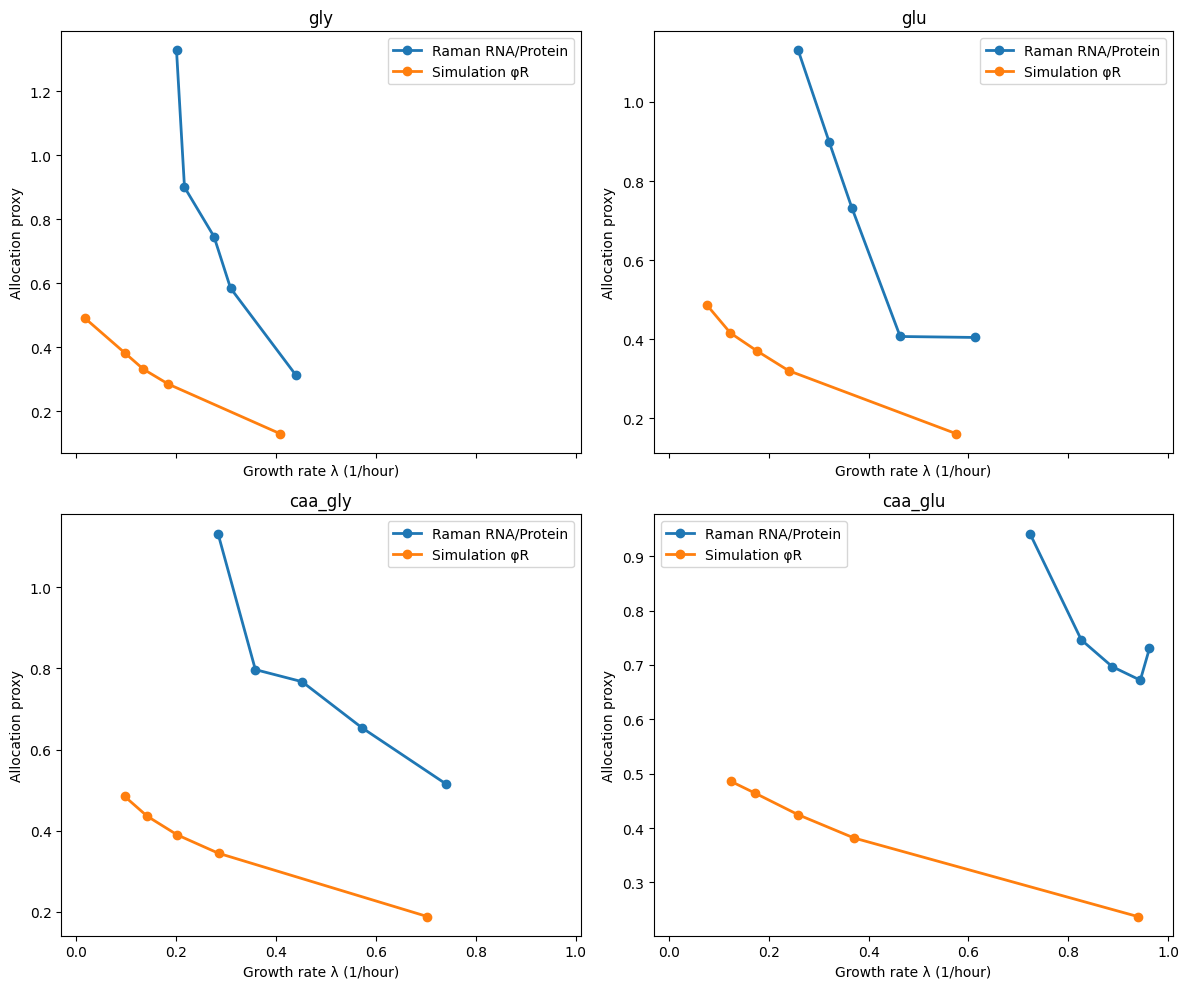

In [ ]:
# ===============================================================
# Raman RNA/Protein extraction + Simulation φR comparison
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# --------------------------------------------------------------
# PARAMETERS
# --------------------------------------------------------------

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]
nutrients  = ["gly", "glu", "caa_gly", "caa_glu"]

NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0

# --------------------------------------------------------------
# HELPERS
# --------------------------------------------------------------

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    r = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )
    q = df["q(t)"] + df["et(t)"] + df["em(t)"]

    ribo_mass = NR * r.to_numpy()
    prot_mass = NX * q.to_numpy()
    return ribo_mass, prot_mass

def compute_growth_rate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)
    active = (
        df["rmr(t)"] +
        df["rmt(t)"] +
        df["rmm(t)"] +
        df["rmq(t)"]
    ).to_numpy()
    return (active * gamma / mass) * 60.0

# --------------------------------------------------------------
# RAMAN DATA
# --------------------------------------------------------------

ratio_df = pd.read_csv("Data/RamanData/rna_protein.csv")
raman_growth = pd.read_csv("Data/RamanData/Raman_growth.csv")

raman_records = []

for nutrient in nutrients:
    for cm in ABX_VALUES:

        col = f"Cm{cm}_{nutrient}"

        if col not in ratio_df.columns:
            continue

        values = ratio_df[col].dropna().values

        raman_records.append({
            "Condition": nutrient,
            "Dose": cm,
            "ratio_mean": np.mean(values),
            "ratio_sd": np.std(values)
        })

df_raman_ratio = pd.DataFrame(raman_records)

# Merge growth + ratio
df_raman = pd.merge(
    raman_growth,
    df_raman_ratio,
    on=["Condition","Dose"]
)

# --------------------------------------------------------------
# SIMULATION φR
# --------------------------------------------------------------

sim_records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        if abx == 0:
            path = f"Data/ns{int(ns*100):03d}.arrow"
        else:
            path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        ribo_mass, prot_mass = compute_mass(df)
        total_mass = ribo_mass + prot_mass

        phiR = ribo_mass / total_mass
        lam = compute_growth_rate(df, total_mass)

        valid = (~np.isnan(phiR)) & (~np.isnan(lam))
        phiR = phiR[valid]
        lam = lam[valid]

        sim_records.append({
            "ns": ns,
            "abx": abx,
            "lambda_mean": lam.mean(),
            "phiR_mean": phiR.mean()
        })

df_sim = pd.DataFrame(sim_records)

# --------------------------------------------------------------
# PLOT PER NUTRIENT
# --------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12,10), sharex=True)

for i, nutrient in enumerate(nutrients):

    ax = axes.flatten()[i]

    # Raman
    sub_raman = df_raman[df_raman["Condition"] == nutrient]
    ax.plot(sub_raman["Value"],
            sub_raman["ratio_mean"],
            marker="o",
            linewidth=2,
            label="Raman RNA/Protein")

    # Simulation (matching ns order)
    ns_val = NS_VALUES[i]
    sub_sim = df_sim[df_sim["ns"] == ns_val]
    ax.plot(sub_sim["lambda_mean"],
            sub_sim["phiR_mean"],
            marker="o",
            linewidth=2,
            label="Simulation φR")

    ax.set_title(nutrient)
    ax.set_xlabel("Growth rate λ (1/hour)")
    ax.set_ylabel("Allocation proxy")
    ax.legend()

plt.tight_layout()
plt.show()


Previously showed:

RNA/Protein ≈ φR in the model.

Now we see:

Raman RNA/Protein behaves like φR under antibiotic stress.

Therefore:

Raman RNA/Protein is behaving like a ribosomal allocation proxy.